# Model comparison — overview & scorecard

Entry point for **decision making**: effort, pipeline outcomes, a cross-dimension KPI scorecard comparing the models on one screen, and a ranking of every run from best to worst. Detailed evidence lives in `10_build`, `20_tests_coverage` and `30_code_metrics`. Iterations are independent samples; only iterations 1–6 are included.

In [1]:
STORY_ID = "CPD-LC-001-001"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-001 | models: ['Kimi-K2.5', 'grok-4.5']
palette: {'Kimi-K2.5': '#2a78d6', 'grok-4.5': '#1baf7a'}


## Iteration summary (master table)

One row per (model, iteration): final build/test/coverage/metrics outcomes,
pipeline stage statuses and attempt counts. `NaN` = the stage produced no
canonical result for that cell. This table backs every chart below.

**Table columns** (one row per run; *final* = last execution of that run)

- `story`, `model`, `iteration` — the run's identity; `iteration` is one independent repetition (1–6) of the story by that model.
- `build_status`, `build_errors`, `build_warnings` — final build outcome (`success`/`failure`) and its compiler error / warning counts.
- `test_status`, `total_tests`, `passed`, `failed`, `skipped`, `pass_rate` — final test execution: overall status, test-method counts by outcome, and passed÷total.
- `line_rate`, `branch_rate` — line / branch coverage (0–1) of the run's final coverage report.
- `median_mi`, `min_mi` — median / worst maintainability index over the final snapshot's types; `max_cc`, `max_coupling`, `max_dit` — worst cyclomatic complexity, class coupling and inheritance depth; `n_types` — types analyzed; `pct_green_types` — share of types with all four flags GREEN; `source_lines`, `executable_lines` — code size totals.
- `tg_status`, `tg_test_methods` — test-generation stage status and emitted test methods; `cg_status`, `cg_files_created`, `cg_files_modified` — code-generation status and file footprint; `ref_status`, `ref_all_green`, `ref_loop_iterations`, `ref_n_remaining_violations` — refactoring status, whether every flag ended GREEN, loop passes spent, violations left.
- `build_attempts`, `test_attempts`, `metrics_attempts` — executions recorded per result tree for the run (1 + retries = effort).

In [3]:
summ = tdd.iteration_summary(STORY_ID, data)
display(summ.round(3))

,story,model,iteration,build_status,build_errors,build_warnings,test_status,total_tests,passed,failed,skipped,pass_rate,line_rate,branch_rate,median_mi,min_mi,max_cc,max_coupling,max_dit,n_types,pct_green_types,source_lines,executable_lines,tg_status,tg_test_methods,cg_status,cg_files_created,cg_files_modified,ref_status,ref_all_green,ref_loop_iterations,ref_n_remaining_violations,build_attempts,test_attempts,metrics_attempts
0,CPD-LC-001-001,Kimi-K2.5,1,success,0,0,success,24,24,0,0,1.0,0.652,0.900,72.5,54,10,21,1,24,0.917,561,73,success,21.0,success,10,14,partial,False,1.0,2,13,8,2
1,CPD-LC-001-001,Kimi-K2.5,2,success,0,0,success,24,24,0,0,1.0,0.551,0.857,71.0,56,5,19,1,25,0.920,576,72,success,21.0,success,10,12,success,True,1.0,0,12,5,3
2,CPD-LC-001-001,Kimi-K2.5,3,success,0,0,success,24,24,0,0,1.0,0.552,0.800,74.0,55,8,22,1,24,0.917,539,68,success,21.0,success,11,13,success,True,0.0,0,6,3,1
3,CPD-LC-001-001,Kimi-K2.5,4,success,0,0,success,24,24,0,0,1.0,0.569,0.889,74.0,55,8,18,1,25,0.920,577,67,success,17.0,success,0,1,partial,False,2.0,1,15,10,4
4,CPD-LC-001-001,Kimi-K2.5,5,success,0,0,success,24,24,0,0,1.0,0.546,0.800,72.5,55,5,15,1,22,0.909,533,66,success,21.0,success,8,13,partial,False,2.0,1,20,4,3
5,CPD-LC-001-001,Kimi-K2.5,6,success,0,0,success,24,24,0,0,1.0,0.545,0.900,74.0,57,8,21,1,23,0.913,493,68,success,21.0,success,10,9,partial,False,1.0,2,13,3,2
6,CPD-LC-001-001,grok-4.5,1,success,0,0,success,24,24,0,0,1.0,0.626,0.643,74.0,63,9,15,1,30,0.967,552,86,success,16.0,success,0,4,success,True,4.0,0,7,6,5
7,CPD-LC-001-001,grok-4.5,2,success,0,0,success,24,24,0,0,1.0,0.556,0.750,74.0,54,6,15,1,29,0.966,618,80,success,21.0,success,11,7,success,True,6.0,0,7,7,7
8,CPD-LC-001-001,grok-4.5,3,success,0,0,success,24,24,0,0,1.0,0.561,0.750,71.0,54,6,15,1,27,0.963,629,76,success,21.0,success,11,9,success,True,3.0,0,5,4,4
9,CPD-LC-001-001,grok-4.5,4,success,0,0,success,24,24,0,0,1.0,0.554,0.750,72.0,54,6,15,1,28,0.964,618,77,success,21.0,success,11,3,success,True,2.0,0,3,3,3


## Effort: executions per iteration

Every retry the agent needed before moving on, per result tree. Taller bars =
more friction. Compare models at the same iteration position.

**Chart columns** — one panel per result tree (`build`, `test`, `metrics`): `iteration` (x) — run position 1–6; `executions` (y) — timestamped executions recorded in that tree for the run (1 + retries); bar color — model.

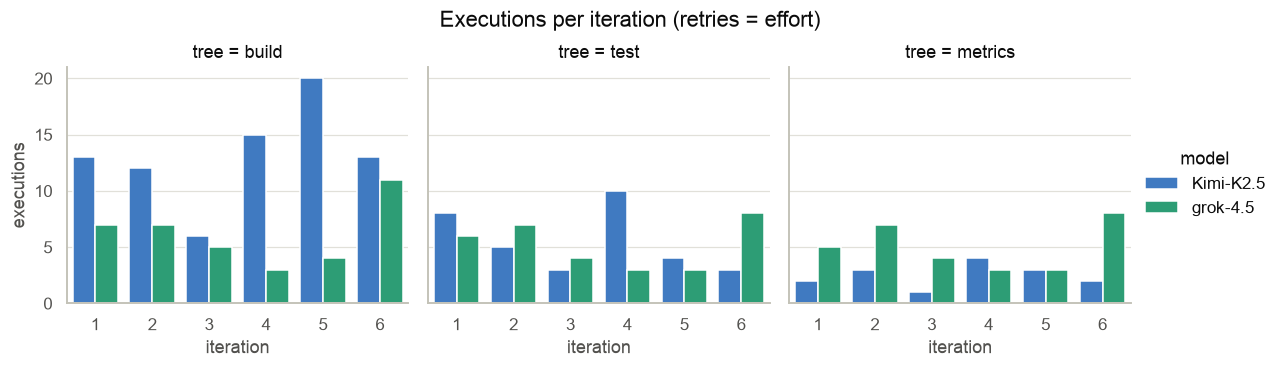

In [4]:
ac = pd.concat([
    tdd.attempt_counts(data["build"], "build"),
    tdd.attempt_counts(data["test"], "test"),
    tdd.attempt_counts(data["metrics_types"], "metrics"),
])
if ac.empty:
    print("No data for this section.")
else:
    g = sns.catplot(data=ac, kind="bar", x="iteration", y="n_attempts",
                    hue="model", col="tree", hue_order=HUE, palette=PAL,
                    height=3.2, aspect=1.1)
    g.set_axis_labels("iteration", "executions")
    g.figure.suptitle("Executions per iteration (retries = effort)", y=1.04)

## Effort distribution per model

Small samples (6 iterations/model), so every point is shown over the box.
A tight low box = the model converges with little friction.

**Chart columns** — one panel per result tree: `model` (x); `executions per iteration` (y) — the same per-run execution counts as above, pooled over iterations; box — median/IQR across runs; black dots — individual runs.

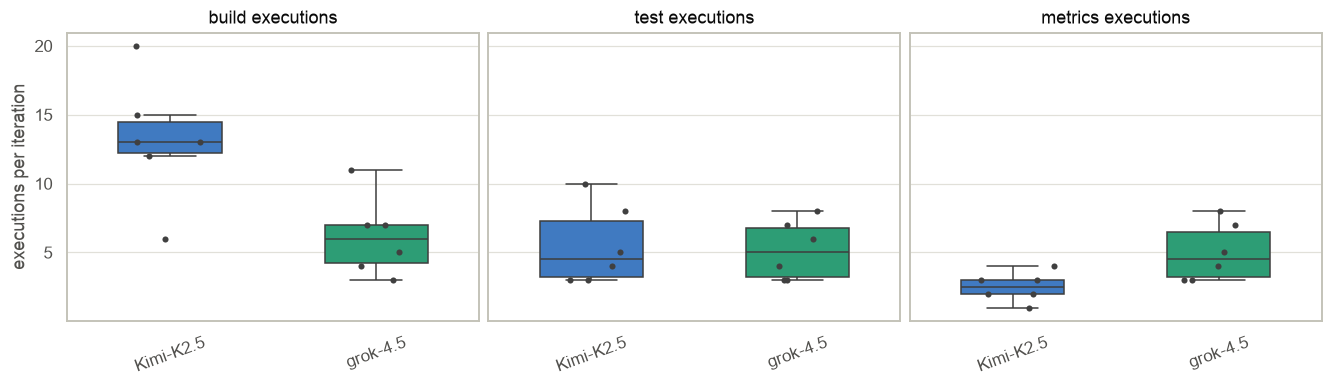

In [5]:
if ac.empty:
    print("No data for this section.")
else:
    trees = list(ac["tree"].unique())
    fig, axes = plt.subplots(1, len(trees), figsize=(4 * len(trees), 3.4), sharey=True)
    for ax, tree in zip(np.atleast_1d(axes), trees):
        sub = ac[ac["tree"] == tree]
        sns.boxplot(data=sub, x="model", y="n_attempts", hue="model", order=HUE,
                    hue_order=HUE, palette=PAL, legend=False, width=0.5,
                    showfliers=False, ax=ax)
        sns.stripplot(data=sub, x="model", y="n_attempts", order=HUE,
                      color=".25", size=4, jitter=0.2, ax=ax)
        ax.set_title(f"{tree} executions")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
    axes_flat = np.atleast_1d(axes)
    axes_flat[0].set_ylabel("executions per iteration")

## Pipeline stage outcomes per cell

One matrix per stage; each cell is (model, iteration). `S` = success,
`P` = partial, `F` = failure; gray = no result recorded.

**Chart columns** — one matrix per pipeline stage (`test-generation`, `code-generation`, `refactoring`): rows — model; columns — `iteration` (run 1–6); cell color + letter — the stage's reported status for that run (`S`uccess / `P`artial / `F`ailure; gray = no result file).

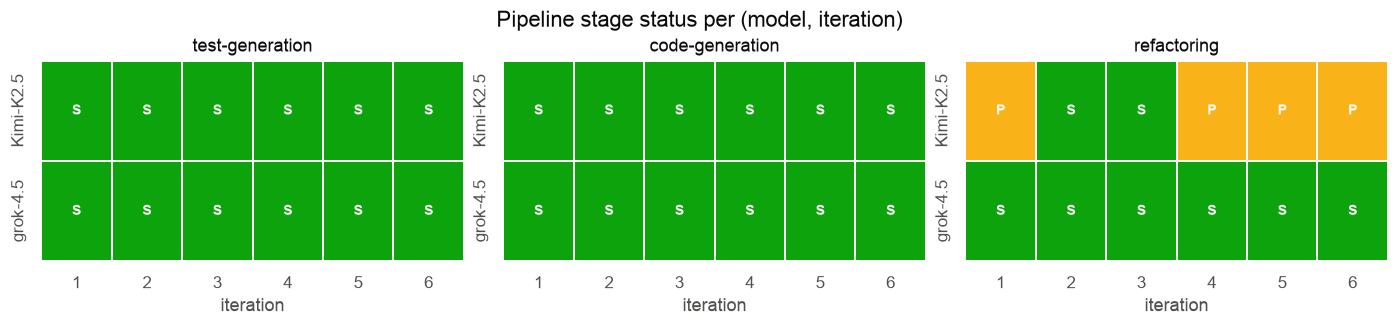

In [6]:
from matplotlib.colors import BoundaryNorm, ListedColormap

stages = data["stages"]
if stages.empty:
    print("No data for this section.")
else:
    order = ["test-generation", "code-generation", "refactoring"]
    code_map = {"failure": 0, "partial": 1, "success": 2}
    abbr = {"failure": "F", "partial": "P", "success": "S"}
    iters = sorted(stages["iteration"].unique())
    cmap = ListedColormap([tdd.STAGE_STATUS_COLORS["failure"],
                           tdd.STAGE_STATUS_COLORS["partial"],
                           tdd.STAGE_STATUS_COLORS["success"]])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    fig, axes = plt.subplots(1, len(order), figsize=(4.2 * len(order), 2.6))
    for ax, stage in zip(np.atleast_1d(axes), order):
        sub = stages[stages["stage"] == stage]
        grid = (sub.pivot(index="model", columns="iteration", values="status")
                   .reindex(index=HUE, columns=iters))
        sns.heatmap(grid.map(code_map.get), cmap=cmap, norm=norm, cbar=False,
                    annot=grid.map(lambda s: abbr.get(s, "")), fmt="",
                    linewidths=1, linecolor="white", ax=ax,
                    annot_kws={"fontsize": 9, "color": "white", "fontweight": "bold"})
        ax.set_facecolor("#f0efec")
        ax.set_title(stage)
        ax.set_ylabel("")
    fig.suptitle("Pipeline stage status per (model, iteration)", y=1.08)

## Refactoring: all-green achievement and loop cost

Left: how often the refactoring loop drove every metric flag to GREEN
(annotated with the raw fraction — n is small). Right: how many loop
iterations it took; points on the dashed line hit the budget ceiling.

**Chart columns** — left: `model` (x); `all-green rate` (y) — share of runs whose refactoring loop ended with every metric flag GREEN, annotated `achieved/runs`. Right: `model` (x); `loop iterations` (y) — refactoring loop passes reported per run (dots — runs; box — spread; dashed line — configured loop budget).

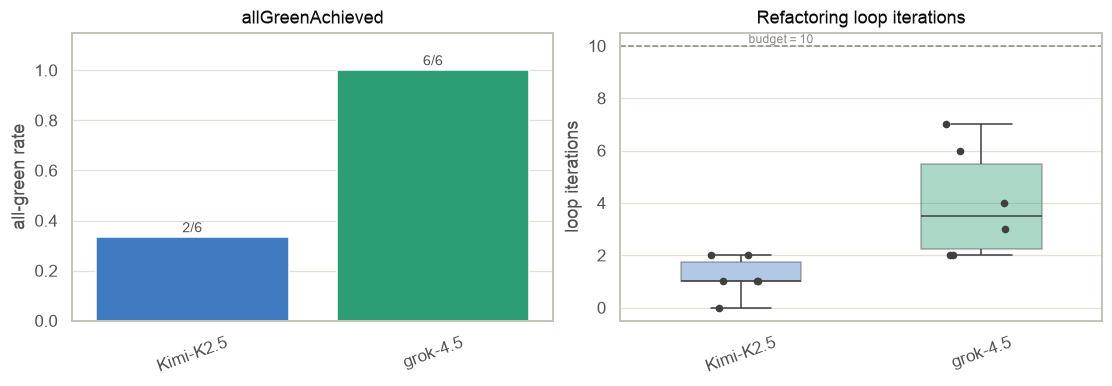

In [7]:
ref = data["stages"].query("stage == 'refactoring'") if not data["stages"].empty else data["stages"]
if ref.empty:
    print("No refactoring results.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

    ag = (ref.assign(all_green=ref["ref_all_green"].map({True: 1.0, False: 0.0}))
             .groupby("model")["all_green"].agg(rate="mean", achieved="sum", n="count")
             .reindex(HUE))
    sns.barplot(x=ag.index, y=ag["rate"], hue=ag.index, hue_order=HUE,
                palette=PAL, legend=False, ax=ax1)
    for i, (_, row) in enumerate(ag.iterrows()):
        ax1.text(i, row["rate"] + 0.02, f"{int(row['achieved'])}/{int(row['n'])}",
                 ha="center", fontsize=9, color=tdd.INK["secondary"])
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("all-green rate")
    ax1.set_xlabel("")
    ax1.set_title("allGreenAchieved")
    ax1.tick_params(axis="x", rotation=20)

    sns.boxplot(data=ref, x="model", y="ref_loop_iterations", hue="model",
                order=HUE, hue_order=HUE, palette=PAL, legend=False,
                width=0.5, showfliers=False, boxprops={"alpha": 0.4}, ax=ax2)
    sns.stripplot(data=ref, x="model", y="ref_loop_iterations", order=HUE,
                  color=".25", size=5, jitter=0.15, ax=ax2)
    ceiling = ref["ref_max_loop_iterations"].max()
    if pd.notna(ceiling):
        ax2.axhline(ceiling, ls="--", color=tdd.INK["muted"], lw=1)
        ax2.text(0.02, ceiling, f" budget = {int(ceiling)}", va="bottom",
                 fontsize=8, color=tdd.INK["muted"])
    ax2.set_ylabel("loop iterations")
    ax2.set_xlabel("")
    ax2.set_title("Refactoring loop iterations")
    ax2.tick_params(axis="x", rotation=20)

## KPI scorecard

All dimensions on one screen. Color = per-column min-max normalization,
oriented so **darker = better** (columns marked ↓ are inverted: lower raw
value is better). Numbers are the **raw** values — read those for decisions;
color only ranks the three models per column.

**Scorecard columns** (rows = models; every cell aggregates that model's runs)

- `build success rate` — share of runs whose final build succeeded.
- `build attempts ↓` — mean build executions per run.
- `test pass rate` — mean final-run pass rate.
- `tests emitted / intent` — mean test methods emitted by test-generation ÷ the story's confirmed intents.
- `line coverage`, `branch coverage` — mean final coverage rates (0–1).
- `median MI` — median over runs of the per-run median maintainability index.
- `% all-GREEN types` — mean share of types with all four metric flags GREEN.
- `all-green rate` — share of refactoring loops that ended all-green.
- `refactor loops ↓` — mean refactoring loop passes per run.

,build success rate,build attempts ↓,test pass rate,tests emitted / intent,line coverage,branch coverage,median MI,% all-GREEN types,all-green rate,refactor loops ↓
model,,,,,,,,,,
Kimi-K2.5,1.0,13.167,1.0,0.968,0.569,0.858,73.25,0.916,0.333,1.167
grok-4.5,1.0,6.167,1.0,0.960,0.569,0.750,73.00,0.965,1.000,4.000


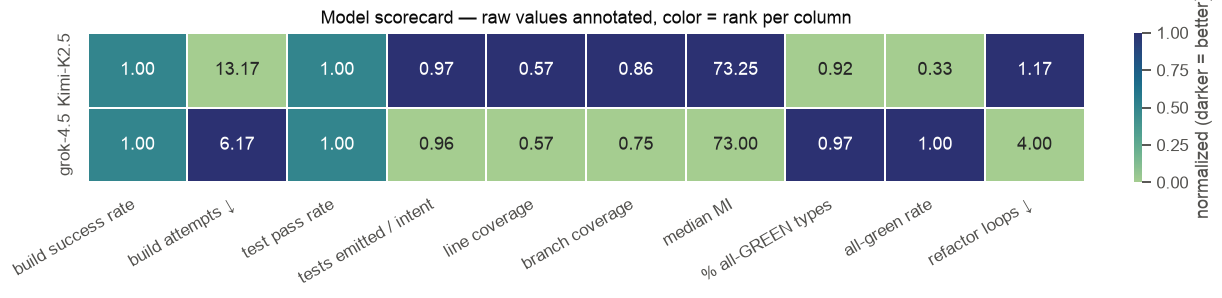

In [8]:
intents_total = data["intents"]["n_intents"].sum() if not data["intents"].empty else np.nan
by_model = summ.groupby("model")
kpis = pd.DataFrame({
    "build success rate": by_model["build_status"].agg(lambda s: s.dropna().eq("success").mean()),
    "build attempts ↓": by_model["build_attempts"].mean(),
    "test pass rate": by_model["pass_rate"].mean(),
    "tests emitted / intent": by_model["tg_test_methods"].mean() / intents_total,
    "line coverage": by_model["line_rate"].mean(),
    "branch coverage": by_model["branch_rate"].mean(),
    "median MI": by_model["median_mi"].median(),
    "% all-GREEN types": by_model["pct_green_types"].mean(),
    "all-green rate": by_model["ref_all_green"].agg(
        lambda s: s.map({True: 1.0, False: 0.0}).mean()),
    "refactor loops ↓": by_model["ref_loop_iterations"].mean(),
}).reindex(HUE)

norm = kpis.copy()
for col in norm:
    v = norm[col].astype(float)
    lo, hi = v.min(), v.max()
    n = (v - lo) / (hi - lo) if hi > lo else pd.Series(0.5, index=v.index)
    norm[col] = 1 - n if col.endswith("↓") else n

annot = kpis.map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}")
fig, ax = plt.subplots(figsize=(11, 2.6))
sns.heatmap(norm.astype(float), annot=annot, fmt="", cmap="crest",
            vmin=0, vmax=1, linewidths=1, linecolor="white",
            cbar_kws={"label": "normalized (darker = better)"}, ax=ax)
ax.set_facecolor("#f0efec")
ax.set_ylabel("")
ax.set_title("Model scorecard — raw values annotated, color = rank per column")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
display(kpis.round(3))

## Best run — all (model, iteration) runs ranked

Which single run of this story is the best? Every run is scored on three
pillars, each an equal-weight mean of its components (`PILLAR_WEIGHTS` sets
the pillar mix):

- **build** — final build succeeds ᵃ, few build errors ʳ, few build warnings ʳ, few build executions ʳ;
- **tests & coverage** — final pass rate ᵃ, line ᵃ and branch ᵃ coverage, confirmed-intents ratio ᵃ, few test executions until the first fully-green run ʳ;
- **refactoring & quality** — % all-GREEN types ᵃ, median MI ᵃ, worst-type MI ᵃ, worst-type threshold flags ᵃ (each metric's worst type mapped GREEN=1 / YELLOW=0.5 / RED=0), low worst-type coupling ʳ, all-green refactoring achieved ᵃ, few remaining violations ʳ, few refactoring loops ʳ, few metrics executions ʳ.

Normalization is two-tier, marked per component: **ᵃ = absolute anchor**
(0–1 rates/ratios used raw, MI÷100, the documented SQA thresholds) — fixed
before this cohort existed and comparable across stories; **ʳ = min–max
within these runs** (open-ended counts have no absolute scale; a flat column
counts 0.5 for everyone; ↓ = lower is better). Missing evidence scores 0 —
producing no result *is* a result. Quality components outnumber effort
components, so verified outcomes outweigh the cost of reaching them.
Self-reported stage statuses are never scored — only tool-measured artifacts
(the one stage metric used, all-green, is cross-checked by the violations
count).

Two weight-independent robustness checks accompany the score: `pareto` —
runs not dominated on all three pillars; only these can rank #1 under *any*
positive weighting (★ in the chart). `top1_share` / `rank_range` — how often
the run wins, and the ranks it spans, across a deterministic 120-point grid
of pillar weightings (each pillar 0.10–0.80 in 0.05 steps, summing to 1).

**Table columns** — row order/`rank` — best to worst by `composite` (the
weighted pillar mean); `build`, `tests & coverage`, `refactoring & quality`
— pillar scores (0–1); `pareto`, `top1_share`, `rank_range` — the robustness
checks above. Then the raw evidence: final build `build_status`,
`build_errors`, `build_warnings` and `build_attempts` (executions); final
`pass_rate`, `line_rate`, `branch_rate`; `intents_ratio` — test-generation's
confirmed intents ÷ the story's confirmed intents; `attempts_to_green` —
first fully-green test execution; `test_attempts` — all test executions
(context, unscored); `median_mi`, `min_mi`, `max_coupling`, `worst_flag` —
final-snapshot metric aggregates; `pct_green_types`; refactoring outcome
(`ref_all_green`, `ref_n_remaining_violations`, `ref_loop_iterations`);
`metrics_attempts`; `source_lines` — code size (context, unscored).

<>:130: SyntaxWarning: invalid escape sequence '\s'
<>:130: SyntaxWarning: invalid escape sequence '\s'
/var/folders/l8/xq7bdxm16pd2kd956l6t9mf00000gn/T/ipykernel_53125/1327312485.py:130: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_title("Runs ranked best \u2192 worst ($\star$ = Pareto-optimal)")


,model,iteration,composite,build,tests & coverage,refactoring & quality,pareto,top1_share,rank_range,build_status,build_errors,build_warnings,build_attempts,pass_rate,line_rate,branch_rate,intents_ratio,attempts_to_green,test_attempts,median_mi,min_mi,max_coupling,worst_flag,pct_green_types,ref_all_green,ref_n_remaining_violations,ref_loop_iterations,metrics_attempts,source_lines
rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,grok-4.5,5,0.818,0.735,0.880,0.837,True,0.625,1–2,success,0,0,4,1.0,0.542,0.857,1.000,1,3,72.0,55,15,0.875,0.963,True,0,2.0,3,593
2,grok-4.5,4,0.816,0.750,0.861,0.836,True,0.375,1–2,success,0,0,3,1.0,0.554,0.750,1.000,1,3,72.0,54,15,0.875,0.964,True,0,2.0,3,618
3,grok-4.5,3,0.795,0.721,0.862,0.803,False,0.000,3–3,success,0,0,5,1.0,0.561,0.750,1.000,1,4,71.0,54,15,0.875,0.963,True,0,3.0,4,629
4,Kimi-K2.5,3,0.777,0.706,0.837,0.787,False,0.000,4–6,success,0,0,6,1.0,0.552,0.800,1.000,2,3,74.0,55,22,0.875,0.917,True,0,0.0,1,539
5,grok-4.5,1,0.766,0.691,0.821,0.785,False,0.000,5–7,success,0,0,7,1.0,0.626,0.643,1.000,2,6,74.0,63,15,0.875,0.967,True,0,4.0,5,552
6,grok-4.5,2,0.755,0.691,0.861,0.712,False,0.000,4–7,success,0,0,7,1.0,0.556,0.750,1.000,1,7,74.0,54,15,0.875,0.966,True,0,6.0,7,618
7,Kimi-K2.5,2,0.739,0.618,0.815,0.785,False,0.000,6–9,success,0,0,12,1.0,0.551,0.857,1.000,3,5,71.0,56,19,0.875,0.920,True,0,1.0,3,576
8,grok-4.5,6,0.726,0.632,0.865,0.680,False,0.000,5–8,success,0,0,11,1.0,0.574,0.750,1.000,1,8,74.0,54,15,0.875,0.968,True,0,7.0,8,662
9,Kimi-K2.5,6,0.670,0.603,0.856,0.551,False,0.000,8–11,success,0,0,13,1.0,0.545,0.900,1.000,2,3,74.0,57,21,0.875,0.913,False,2,1.0,2,493


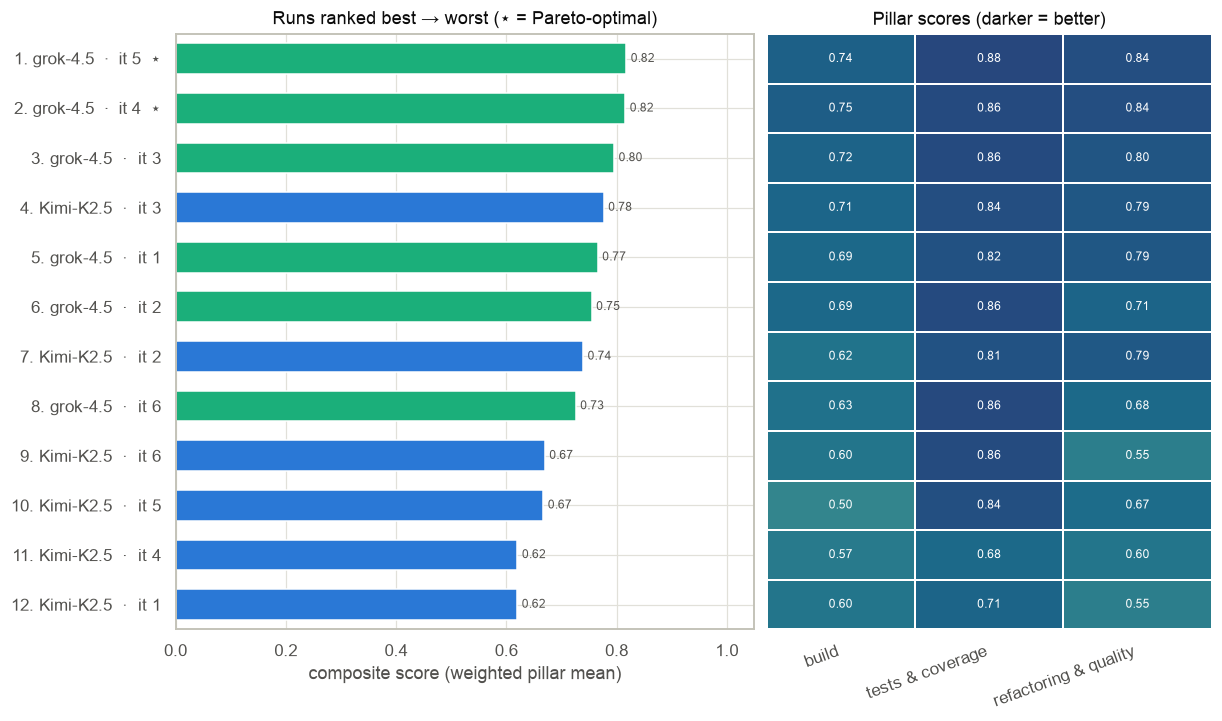

In [9]:
if summ.empty:
    print("No data for this section.")
else:
    LOW = "\u2193"  # suffix: lower raw value is better -> inverted (rel components)
    PILLAR_WEIGHTS = {"build": 1.0, "tests & coverage": 1.0, "refactoring & quality": 1.0}
    key = ["model", "iteration"]
    runs = summ.set_index(key)

    # -- derived criteria not in the master table ---------------------------
    t = data["test"]
    green = t[t["status"] == "success"] if not t.empty else t
    runs["attempts_to_green"] = (green.groupby(key)["attempt"].min()
                                 if not green.empty else np.nan)
    stg = data["stages"]
    tg = stg[stg["stage"] == "test-generation"] if not stg.empty else stg
    intents_total = data["intents"]["n_intents"].sum() if not data["intents"].empty else np.nan
    runs["intents_ratio"] = (tg.set_index(key)["tg_intents_confirmed"] / intents_total
                             if not tg.empty else np.nan)

    FLAG = {"GREEN": 1.0, "YELLOW": 0.5, "RED": 0.0}

    def worst_flag_score(g):
        """Documented-threshold flag of each metric's worst type, averaged."""
        vals = []
        for col, flag_col, worst in (("mi", "mi_flag", "idxmin"),
                                     ("cc", "cc_flag", "idxmax"),
                                     ("coupling", "coupling_flag", "idxmax"),
                                     ("dit", "dit_flag", "idxmax")):
            s = g[col].dropna()
            if not s.empty:
                vals.append(FLAG.get(g.loc[getattr(s, worst)(), flag_col], 0.0))
        return np.mean(vals) if vals else np.nan

    mt = tdd.finals(data["metrics_types"])
    runs["worst_flag"] = (mt.groupby(key)[["mi", "mi_flag", "cc", "cc_flag",
                                           "coupling", "coupling_flag",
                                           "dit", "dit_flag"]].apply(worst_flag_score)
                          if not mt.empty else np.nan)

    # -- two-tier scoring ----------------------------------------------------
    def score(series, norm, invert=False):
        """abs: raw 0-1 anchor (clipped); rel: min-max within these runs
        (flat -> 0.5). Missing evidence always scores 0 (worst)."""
        v = pd.to_numeric(series, errors="coerce")
        if norm == "abs":
            return v.clip(0.0, 1.0).fillna(0.0)
        lo, hi = v.min(), v.max()
        if pd.isna(lo):
            return pd.Series(0.0, index=v.index)
        n = (v - lo) / (hi - lo) if hi > lo else v.where(v.isna(), 0.5)
        return (1.0 - n if invert else n).fillna(0.0)

    PILLARS = {
        "build": [
            ("final build ok", "abs", (runs["build_status"] == "success").astype(float)),
            (f"build errors {LOW}", "rel", runs["build_errors"]),
            (f"build warnings {LOW}", "rel", runs["build_warnings"]),
            (f"build executions {LOW}", "rel", runs["build_attempts"]),
        ],
        "tests & coverage": [
            ("pass rate", "abs", runs["pass_rate"]),
            ("line coverage", "abs", runs["line_rate"]),
            ("branch coverage", "abs", runs["branch_rate"]),
            ("intents confirmed", "abs", runs["intents_ratio"]),
            (f"attempts to green {LOW}", "rel", runs["attempts_to_green"]),
        ],
        "refactoring & quality": [
            ("% all-GREEN types", "abs", runs["pct_green_types"]),
            ("median MI", "abs", runs["median_mi"] / 100.0),
            ("worst-type MI", "abs", runs["min_mi"] / 100.0),
            ("worst-type flags", "abs", runs["worst_flag"]),
            (f"worst coupling {LOW}", "rel", runs["max_coupling"]),
            ("all-green refactor", "abs", runs["ref_all_green"].map({True: 1.0, False: 0.0})),
            (f"violations left {LOW}", "rel", runs["ref_n_remaining_violations"]),
            (f"refactor loops {LOW}", "rel", runs["ref_loop_iterations"]),
            (f"metrics executions {LOW}", "rel", runs["metrics_attempts"]),
        ],
    }
    for pillar, comps in PILLARS.items():
        scored = pd.DataFrame({n: score(v, norm, n.endswith(LOW)) for n, norm, v in comps})
        runs[pillar] = scored.mean(axis=1)
    w = pd.Series(PILLAR_WEIGHTS)
    runs["composite"] = (runs[list(PILLARS)] * w).sum(axis=1) / w.sum()

    ranking = (runs.reset_index()
                   .sort_values(["composite", "model", "iteration"],
                                ascending=[False, True, True])
                   .reset_index(drop=True))
    ranking.index = pd.RangeIndex(1, len(ranking) + 1, name="rank")

    # -- weight-independent robustness --------------------------------------
    P = ranking[list(PILLARS)].to_numpy(dtype=float)
    n_runs = len(P)
    dominated = [any((P[j] >= P[i]).all() and (P[j] > P[i]).any()
                     for j in range(n_runs) if j != i) for i in range(n_runs)]
    ranking["pareto"] = ~np.array(dominated)

    # deterministic simplex grid: each pillar weight 0.10-0.80 in 0.05 steps
    grid = np.array([(a, b, 20 - a - b) for a in range(2, 17) for b in range(2, 17)
                     if 2 <= 20 - a - b <= 16], dtype=float) / 20.0
    top1 = np.zeros(n_runs)
    rank_lo, rank_hi = np.full(n_runs, n_runs), np.ones(n_runs)
    for wv in grid:
        comp = P @ wv
        order = np.argsort(-comp, kind="stable")
        rnk = np.empty(n_runs, dtype=int)
        rnk[order] = np.arange(1, n_runs + 1)
        top1[order[0]] += 1
        rank_lo, rank_hi = np.minimum(rank_lo, rnk), np.maximum(rank_hi, rnk)
    ranking["top1_share"] = top1 / len(grid)
    ranking["rank_range"] = [f"{int(lo)}\u2013{int(hi)}"
                             for lo, hi in zip(rank_lo, rank_hi)]

    # -- chart ---------------------------------------------------------------
    labels = [f"{r}. {m}  \u00b7  it {i}" + (r"  $\star$" if p else "")
              for r, m, i, p in zip(ranking.index, ranking["model"],
                                    ranking["iteration"], ranking["pareto"])]
    y = np.arange(n_runs) + 0.5                 # match heatmap row centers
    fig = plt.figure(figsize=(11, 0.42 * n_runs + 1.4))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])

    ax1 = fig.add_subplot(gs[0])
    bars = ax1.barh(y, ranking["composite"], height=0.62,
                    color=[PAL[m] for m in ranking["model"]])
    ax1.bar_label(bars, fmt="%.2f", fontsize=8, color=tdd.INK["secondary"], padding=3)
    ax1.set_yticks(y, labels)
    ax1.set_ylim(n_runs, 0)                     # rank 1 on top
    ax1.set_xlim(0, 1.05)
    ax1.set_xlabel("composite score (weighted pillar mean)")
    ax1.set_title("Runs ranked best \u2192 worst ($\star$ = Pareto-optimal)")

    ax2 = fig.add_subplot(gs[1])
    sns.heatmap(ranking[list(PILLARS)].astype(float), cmap="crest", vmin=0, vmax=1,
                annot=True, fmt=".2f", linewidths=1, linecolor="white",
                yticklabels=False, cbar=False, annot_kws={"fontsize": 8}, ax=ax2)
    ax2.set_ylabel("")
    ax2.set_title("Pillar scores (darker = better)")
    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

    detail_cols = ["build_status", "build_errors", "build_warnings", "build_attempts",
                   "pass_rate", "line_rate", "branch_rate", "intents_ratio",
                   "attempts_to_green", "test_attempts",
                   "median_mi", "min_mi", "max_coupling", "worst_flag",
                   "pct_green_types", "ref_all_green", "ref_n_remaining_violations",
                   "ref_loop_iterations", "metrics_attempts", "source_lines"]
    front = ["model", "iteration", "composite"] + list(PILLARS) + \
            ["pareto", "top1_share", "rank_range"]
    display(ranking[front + detail_cols].round(3))

## Sanity checks

In [10]:
fb = tdd.finals(data["build"])
if not fb.empty:
    assert fb.groupby(["story", "model", "iteration"]).size().max() == 1
    assert fb["ts"].notna().all()
if not data["coverage"].empty:
    assert data["coverage"]["line_rate"].between(0, 1).all()
assert summ["iteration"].max() <= 6, "iterations beyond 6 must be excluded"
assert len(ranking) == len(summ), "ranking must cover every (model, iteration) cell"
assert ranking["composite"].between(0, 1).all(), "composite scores must stay in [0, 1]"
assert bool(ranking["pareto"].iloc[0]), "weighted winner must be Pareto-optimal"
assert abs(ranking["top1_share"].sum() - 1.0) < 1e-9, "top-1 shares must sum to 1"
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings")

sanity checks passed | 0 load warnings
